# Evidencia de ingesta Guardian Sentiment

> Cuaderno de validación reproducible del pipeline ETL de noticias de The Guardian sobre `alternative_data.fact_guardian_sentiment`, con agregación 4h, scoring FinBERT cuando existe texto analizable y artefactos exportables para la memoria del TFG.

## Contexto y motivación

Guardian no es una fuente de mercado como la ingesta OHLCV (`02_evidencia_ingesta_ohlcv.ipynb`, `notebooks/01_ingesta/ohlcv/`), ni mide actividad económica nativa como *on-chain*. Su valor está en otro sitio: aporta una señal de **atención mediática** y, solo cuando hay texto suficiente para analizar, una lectura de **tono informativo** (*FinBERT*) alrededor de los criptoactivos.

Esa diferencia obliga a validar la fuente con cuidado. Una tabla puede estar completa en términos de buckets 4h y, aun así, tener una señal de sentimiento débil para algunos símbolos. Por eso este cuaderno separa dos preguntas: si la ingesta está técnicamente bien construida y si la cobertura *FinBERT* es suficiente para usarla como señal por activo.

La evidencia se organiza como un cuaderno de revisión, no como un volcado de logs:

- ejecuta el validador end-to-end de Guardian capturando el registro técnico fuera de la salida visible;
- resume la matriz de comprobaciones obligatorias y no obligatorias;
- cuantifica cobertura temporal, continuidad 4h, duplicados, nulos y cobertura *FinBERT*;
- compara el arranque efectivo con otras fuentes del proyecto;
- revisa auditoría de ingesta e inventario *parquet* crudo;
- exporta JSON/CSV versionados en `reports/validation/guardian/`.

El flujo está pensado para `Kernel > Restart Kernel and Run All` y sigue el orden editorial de los otros cuadernos de evidencia.

## 1. Configuración del entorno

Se localiza la raíz del proyecto buscando hacia arriba hasta encontrar `scripts/validate_guardian_pipeline.py`. Esto permite ejecutar el cuaderno desde `notebooks/01_ingesta/guardian/`, desde la raíz del repositorio o desde el contenedor Docker (raíz `/app`).

También se guardan metadatos mínimos de ejecución (`fecha_hora_utc`, raíz, versión de Python y plataforma). No afectan a las comprobaciones, pero hacen que la evidencia exportada sea trazable si se revisa más adelante.


In [1]:
from __future__ import annotations

import contextlib
import importlib
import io
import json
import platform
import sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from sqlalchemy import text

ROOT = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "scripts" / "validate_guardian_pipeline.py").exists():
        ROOT = candidate
        break

assert ROOT is not None, "No se encontró la raíz del proyecto (falta scripts/validate_guardian_pipeline.py)."
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import scripts.validate_guardian_pipeline as val
from src.config.settings import Settings
from src.utils.database import create_db_engine

val = importlib.reload(val)  # Alinea la caché del kernel con el código en disco

SETTINGS_PATH = ROOT / "config" / "settings.yaml"
settings = Settings.load_from_yaml(SETTINGS_PATH)
guardian_config = settings.alternative_data.guardian_sentiment

GUARDIAN_SCHEMA = "alternative_data"
GUARDIAN_TABLE = "fact_guardian_sentiment"
GUARDIAN_FULL_TABLE = f"{GUARDIAN_SCHEMA}.{GUARDIAN_TABLE}"
GUARDIAN_SYMBOLS = ("BTCUSDT", "ETHUSDT", "BNBUSDT", "XRPUSDT", "SOLUSDT")
GUARDIAN_MARKET_SYMBOL = "MARKET"
GUARDIAN_ENTITIES = [("market_wide", GUARDIAN_MARKET_SYMBOL)] + [
    ("symbol", symbol) for symbol in GUARDIAN_SYMBOLS
]
GUARDIAN_RAW_DIR = Path(
    guardian_config.parquet.snapshot_dir
    if guardian_config is not None
    else ROOT / "data" / "01_raw" / "guardian"
).resolve()
GUARDIAN_OUTPUT_DIR = ROOT / "reports" / "validation" / "guardian"

FECHA_CORTE = getattr(val, "_DEFAULT_FREEZE_TARGET_DATE")
RUN_TIMESTAMP = datetime.now(timezone.utc)
RUN_STAMP = RUN_TIMESTAMP.strftime("%Y%m%dT%H%M%SZ")

run_meta = {
    "fecha_hora_utc": RUN_TIMESTAMP.isoformat(),
    "raiz_proyecto": str(ROOT),
    "python": platform.python_version(),
    "plataforma": platform.platform(),
}
run_meta


{'fecha_hora_utc': '2026-06-03T23:31:54.363423+00:00',
 'raiz_proyecto': '/app',
 'python': '3.10.19',
 'plataforma': 'Linux-5.15.133.1-microsoft-standard-WSL2-x86_64-with-glibc2.36'}

## 2. Ejecución del validador end-to-end

En esta celda se invoca el validador `scripts/validate_guardian_pipeline.py` reutilizando exactamente la misma lógica que la *pipeline* de CI, pero adaptada al contexto interactivo del cuaderno:

- Se redirige `stdout`/`stderr` a un buffer (`logs_tecnicos`) en la propia celda para no saturar la salida del cuaderno con el logging técnico del validador, dejándolo disponible en memoria por si se necesita depurar.
- Si la conexión a SQL falla o la tabla `alternative_data.fact_guardian_sentiment` no está lista, las comprobaciones aguas abajo se marcan como `SKIP` en lugar de lanzar una excepción, dejando un informe parcial pero coherente.
- Con BD operativa, se ejecutan en cadena: suites unitaria e integración con BD -> calidad mínima (PK, conteos no negativos, nulos, frescura, rejilla 4h) -> uniformidad de esquema entre símbolos -> cobertura FinBERT (`SENTIMENT_COVERAGE`) -> alineación temporal (`TEMPORAL_ALIGNMENT`) -> cobertura freeze (`FREEZE_COVERAGE`) por entidad (`scope`, `symbol`) hasta el bucket 4h de **2026-02-28**.
- La evidencia de auditoría en `alternative_data.ingestion_runs`/`ingestion_events` se valida cuando la integración con BD ha pasado.
- Finalmente se construye la **matriz de aceptación** (`_build_acceptance_matrix`) que define qué comprobaciones son obligatorias para considerar el ETL aceptado.

El resultado es la tabla `summary_df`, donde cada fila es una comprobación con su estado (`PASS`/`FAIL`/`SKIP`), si es requerida y un detalle legible. Esta tabla es el semáforo de alto nivel del ETL.


In [2]:
# Redirige el validador a un buffer, ejecuta comprobaciones y construye el `summary_df`

val.results.clear()

validator_logs_buffer = io.StringIO()
with contextlib.redirect_stdout(validator_logs_buffer), contextlib.redirect_stderr(validator_logs_buffer):
    db_ready = val.check_db_connection()
    val.check_guardian_table()
    val.run_unit_suite()

    if db_ready and val.results.get("TABLES_READY") == val.PASS:
        val.run_db_integration_suite()
        val.check_data_quality()
        val.check_schema_uniformity()
        val.check_sentiment_coverage()
        val.check_temporal_alignment()
        val.check_freeze_coverage(**{"target_date": FECHA_CORTE})
    else:
        val.results["DB_INTEGRATION"] = val.SKIP
        val.set_status(val.results, check_id="DATA_QUALITY_MIN", status=val.SKIP)
        val.results["SCHEMA_UNIFORMITY"] = val.SKIP
        val.results["SENTIMENT_COVERAGE"] = val.SKIP
        val.results["TEMPORAL_ALIGNMENT"] = val.SKIP
        val.results["FREEZE_COVERAGE"] = val.SKIP

    val.check_audit_evidence(
        db_integration_passed=val.results.get("DB_INTEGRATION") == val.PASS,
    )

    acceptance_matrix = val._build_acceptance_matrix(
        **{"target_date": FECHA_CORTE},
        db_ready=db_ready,
        table_ready=val.results.get("TABLES_READY") == val.PASS,
    )
    accepted, actionable_failures = val._print_summary(acceptance_matrix)

logs_tecnicos = validator_logs_buffer.getvalue()
matrix_required = {str(row["check_id"]): bool(row["required"]) for row in acceptance_matrix}


# Mapea `id_check` a un texto de detalle legible según el estado
def detalle_check(check_id: str, status: str) -> str:
    if status == val.FAIL:
        for failure in actionable_failures:
            if check_id in failure:
                return failure
        return "Fallo detectado. Revisar el registro de la validación para diagnóstico."

    if status == val.SKIP:
        if check_id == "FREEZE_COVERAGE" and not FECHA_CORTE:
            return "No aplica en esta ejecución."
        return "No ejecutado por precondiciones no cumplidas."

    if check_id == "INTEGRATION":
        return "Suite unitaria Guardian Sentiment ejecutada correctamente."
    if check_id == "DB_INTEGRATION":
        return "Suite db_integration Guardian ejecutada correctamente."
    if check_id == "AUDIT_RUNS":
        return "Evidencia de auditoría en ingestion_runs (cubierta por tests DB si aplica)."
    if check_id == "AUDIT_EVENTS":
        return "Evidencia de auditoría en ingestion_events (cubierta por tests DB si aplica)."
    if check_id == "DATA_QUALITY_MIN":
        return "Sin duplicados por PK, conteos >= 0, sin NULLs, frescura adecuada y grid 4h."
    if check_id == "SCHEMA_UNIFORMITY":
        return "Paridad de columnas estructurales obligatorias entre los 5 símbolos."
    if check_id == "SENTIMENT_COVERAGE":
        pct = int(round(val._SENTIMENT_COVERAGE_MIN_RATIO * 100))
        return (
            "Cada símbolo debe tener score FinBERT suficiente; con "
            f">= {val._SENTIMENT_COVERAGE_MIN_ROWS_FOR_RATIO} buckets, "
            f"el ratio mínimo de `sentiment_mean` no nulo es {pct}%."
        )
    if check_id == "TEMPORAL_ALIGNMENT":
        return "MIN(bucket_4h) no posterior a la fecha de arranque configurada más tolerancia."
    if check_id == "FREEZE_COVERAGE":
        return (
            f"Cobertura hasta fecha de corte {FECHA_CORTE}: "
            "MAX(bucket_4h) alcanza el día calendario requerido por símbolo."
        )
    return "Comprobación validada correctamente."


# Vuelve a estructurar en tabla: una fila por comprobación con requerido y detalle
summary_rows = []
for check_id, label in val._CHECK_LABELS.items():
    status = val.results.get(check_id, val.SKIP)
    summary_rows.append(
        {
            "id_check": check_id,
            "etiqueta": label,
            "estado": status,
            "requerido": "Sí" if matrix_required.get(check_id, False) else "No",
            "detalle": detalle_check(check_id, status),
        }
    )

summary_df = pd.DataFrame(summary_rows)
summary_df


,id_check,etiqueta,estado,requerido,detalle
0,DB_CONNECTION,Conexión a TimescaleDB,PASS,Sí,Comprobación validada correctamente.
1,TABLES_READY,Tabla alternative_data.fact_guardian_sentiment...,PASS,Sí,Comprobación validada correctamente.
2,INTEGRATION,Suite unitaria Guardian Sentiment,PASS,Sí,Suite unitaria Guardian Sentiment ejecutada co...
3,DB_INTEGRATION,Suite de integración con BD Guardian,PASS,Sí,Suite db_integration Guardian ejecutada correc...
4,AUDIT_RUNS,Evidencia en alternative_data.ingestion_runs,PASS,Sí,Evidencia de auditoría en ingestion_runs (cubi...
5,AUDIT_EVENTS,Evidencia en alternative_data.ingestion_events,PASS,Sí,Evidencia de auditoría en ingestion_events (cu...
6,DATA_QUALITY_MIN,Deduplicación PK + conteos >= 0 + sin NULLs + ...,PASS,Sí,"Sin duplicados por PK, conteos >= 0, sin NULLs..."
7,SCHEMA_UNIFORMITY,Paridad de columnas estructurales (DDL NOT NUL...,PASS,Sí,Paridad de columnas estructurales obligatorias...
8,SENTIMENT_COVERAGE,FinBERT por símbolo: presencia + ratio mínima ...,FAIL,Sí,SENTIMENT_COVERAGE (FinBERT por símbolo: prese...
9,TEMPORAL_ALIGNMENT,MIN(bucket_4h) no posterior a start_date YAML ...,PASS,Sí,MIN(bucket_4h) no posterior a la fecha de arra...


### 2.1. Lectura de la matriz de aceptación

Las comprobaciones devueltas cubren las capas críticas del ETL de Guardian Sentiment:

| Capa | Comprobaciones asociadas | Por qué importa |
|---|---|---|
| **Infraestructura** | `DB_CONNECTION`, `TABLES_READY` | Sin BD viva ni `fact_guardian_sentiment` creada, no hay nada que validar |
| **Pipeline / tests** | `INTEGRATION`, `DB_INTEGRATION` | Confirma que el código ETL y la persistencia en BD pasan las suites automatizadas |
| **Auditoría** | `AUDIT_RUNS`, `AUDIT_EVENTS` | Cada ejecución queda trazada en `alternative_data.ingestion_runs`/`ingestion_events` |
| **Calidad de señal** | `DATA_QUALITY_MIN`, `SCHEMA_UNIFORMITY`, `SENTIMENT_COVERAGE`, `TEMPORAL_ALIGNMENT` | Unicidad de PK, paridad estructural entre símbolos, ratio mínimo de `sentiment_mean` no nulo por FinBERT y arranque temporal alineado con la configuración |
| **Cobertura temporal** | `FREEZE_COVERAGE` | Para cada entidad `(scope, symbol)`, `MAX(bucket_4h) >=` bucket 4h de corte **2026-02-28** |

El resultado no debe leerse como una aceptación plana. La ingesta existe, la tabla está disponible, la auditoría se registra y la estructura temporal es consistente. **En esta ejecución** (**2026-06-03**, `stamp` `20260603T232158Z`), las **once** comprobaciones muestran **diez** en `PASS` y `SENTIMENT_COVERAGE` en `FAIL`; el export cierra con resultado global `FAIL` (véase `summary_df` y el print de exportación). Si alguna comprobación aparece en `FAIL`, la columna `detalle` apunta a la pista accionable (símbolo con cobertura *FinBERT* insuficiente, hueco hasta el freeze, etc.).

La conclusión realista es que Guardian queda útil como fuente de **actividad mediática** y como señal agregada parcial, pero no necesariamente como sentimiento denso y homogéneo para todos los activos. Esa distinción es importante para no sobreinterpretar la fuente en etapas de modelado.


## 3. Evidencias posteriores al validador

Tras el validador end-to-end (sección 2), el cuaderno recorre en orden las comprobaciones siguientes. La consulta SQL de cobertura se calcula en la celda inmediata; el resto se ejecuta al continuar con `Run All`.

1. **Cobertura por (`scope`, `symbol`)** en `fact_guardian_sentiment`: filas, primer y último `bucket_4h`, buckets y días únicos por entidad (símbolo y `market_wide`).
2. **Duplicados** por clave lógica `(scope, symbol, bucket_4h)`.
3. **Cobertura FinBERT por símbolo** mediante el ratio de buckets con `sentiment_mean` no nulo (no es imputación de mercado, es cobertura de señal).
4. **Consistencia de atributos**: nulos, valores negativos en conteos, duplicados de PK y alineación en rejilla 4h en una sola vista compacta.
5. **Series temporales 4h** del volumen de artículos (`article_count`) y del sentimiento medio FinBERT (`sentiment_mean`) por símbolo.
6. **Muestra de filas recientes** por entidad (`scope`, `symbol`) con conteos, probabilidades y momento de ingesta.
7. **Auditoría de ingesta**: resumen por modo histórico/live y diagnóstico básico de la cola en vivo.
8. **Inventario de Parquet raw** bajo `data/01_raw/guardian/`.
9. **Exportación** de tablas y JSON/CSV versionados en `reports/validation/guardian/`.

### 3.1. Resultados: cobertura

Se muestra la cobertura por `(scope, symbol)` cubriendo los símbolos del universo (`BTCUSDT`, `ETHUSDT`, `BNBUSDT`, `XRPUSDT`, `SOLUSDT`) y el agregado `market_wide`, de modo que una entidad ausente quede visible con ceros en lugar de omitirse del informe.

In [3]:
# Conecta, agrega por entidad y levanta la vista con columnas en castellano
evidencia_cobertura_df = pd.DataFrame()
engine_logs_buffer = io.StringIO()
with contextlib.redirect_stdout(engine_logs_buffer), contextlib.redirect_stderr(engine_logs_buffer):
    engine = create_db_engine()

if engine:
    q_cobertura = text(
        f"""
        SELECT scope,
               symbol,
               MIN(bucket_4h)              AS first_bucket,
               MAX(bucket_4h)              AS last_bucket,
               COUNT(*)                    AS total_rows,
               COUNT(DISTINCT bucket_4h)   AS distinct_buckets,
               COUNT(DISTINCT bucket_4h::date) AS distinct_days
        FROM {GUARDIAN_FULL_TABLE}
        GROUP BY scope, symbol
        ORDER BY scope, symbol;
        """
    )
    evidencia_cobertura_df = pd.read_sql(q_cobertura, engine)

columnas_cobertura = {
    "scope": "ámbito",
    "symbol": "símbolo",
    "first_bucket": "primer_bucket",
    "last_bucket": "último_bucket",
    "total_rows": "total_filas",
    "distinct_buckets": "buckets_únicos",
    "distinct_days": "días_únicos",
}
evidencia_cobertura_vista_df = evidencia_cobertura_df.rename(columns=columnas_cobertura)
evidencia_cobertura_vista_df


,ámbito,símbolo,primer_bucket,último_bucket,total_filas,buckets_únicos,días_únicos
0,market_wide,MARKET,2017-01-01 00:00:00+00:00,2026-05-20 20:00:00+00:00,20557,20557,3427
1,symbol,BNBUSDT,2017-01-01 00:00:00+00:00,2026-04-18 20:00:00+00:00,20370,20370,3395
2,symbol,BTCUSDT,2017-01-01 00:00:00+00:00,2026-04-22 16:00:00+00:00,20389,20389,3399
3,symbol,ETHUSDT,2017-01-01 00:00:00+00:00,2026-05-20 20:00:00+00:00,20557,20557,3427
4,symbol,SOLUSDT,2017-01-01 00:00:00+00:00,2026-04-18 20:00:00+00:00,20370,20370,3395
5,symbol,XRPUSDT,2017-01-01 00:00:00+00:00,2026-04-18 20:00:00+00:00,20370,20370,3395


## 4. Consistencia, duplicados e integridad de señal

### 4.1. Duplicados por clave lógica

La granularidad de Guardian es `(scope, symbol, bucket_4h)`. Esta tabla replica el patrón de lectura usado en otros cuadernos: total de filas, buckets únicos y duplicados por clave lógica. Un resultado con `duplicados_pk = 0` en todas las entidades confirma la unicidad estructural de la fact.

In [4]:
# Compara el conteo de filas frente al conteo distinto de `bucket_4h` por entidad
duplicados_pk_df = pd.DataFrame()

if engine:
    q_duplicados = text(
        f"""
        SELECT scope AS ambito,
               symbol AS simbolo,
               COUNT(*)                            AS total_filas,
               COUNT(DISTINCT bucket_4h)           AS timestamps_unicos,
               COUNT(*) - COUNT(DISTINCT bucket_4h) AS duplicados_pk
        FROM {GUARDIAN_FULL_TABLE}
        GROUP BY scope, symbol
        ORDER BY scope, symbol;
        """
    )
    duplicados_pk_df = pd.read_sql(q_duplicados, engine)
    if not duplicados_pk_df.empty:
        duplicados_pk_df = duplicados_pk_df.rename(
            columns={"ambito": "ámbito", "simbolo": "símbolo", "timestamps_unicos": "timestamps_únicos"}
        )

duplicados_pk_df


,ámbito,símbolo,total_filas,timestamps_únicos,duplicados_pk
0,market_wide,MARKET,20557,20557,0
1,symbol,BNBUSDT,20370,20370,0
2,symbol,BTCUSDT,20389,20389,0
3,symbol,ETHUSDT,20557,20557,0
4,symbol,SOLUSDT,20370,20370,0
5,symbol,XRPUSDT,20370,20370,0


### 4.2. Cobertura FinBERT por símbolo

Aquí está el hallazgo más importante de la fuente. La tabla conserva el esquema de integridad usado en otras evidencias, pero la interpretación cambia: las filas sin score no son imputaciones de mercado, sino buckets donde no hubo sentimiento FinBERT disponible. Por eso la lectura correcta es **cobertura de señal**, no calidad de precio.

In [5]:
# Cuantifica la señal FinBERT: nulos y cobertura por símbolo; renombra columnas para lectura clara en tablas
integridad_df = pd.DataFrame()

if engine:
    q_integridad = text(
        f"""
        SELECT symbol AS simbolo,
               COUNT(*)                                                   AS total_filas,
               SUM(CASE WHEN sentiment_mean IS NULL THEN 1 ELSE 0 END)    AS filas_imputadas,
               SUM(CASE WHEN sentiment_mean IS NOT NULL THEN 1 ELSE 0 END) AS filas_reales,
               ROUND(
                   100.0 * SUM(CASE WHEN sentiment_mean IS NOT NULL THEN 1 ELSE 0 END)
                   / NULLIF(COUNT(*), 0), 4
               )                                                          AS pct_integridad_real
        FROM {GUARDIAN_FULL_TABLE}
        GROUP BY symbol
        ORDER BY symbol;
        """
    )
    integridad_df = pd.read_sql(q_integridad, engine)

cobertura_sentimiento_vista_df = integridad_df.rename(columns={
    "simbolo": "símbolo",
    "filas_imputadas": "filas_sin_score_finbert",
    "filas_reales": "filas_con_score_finbert",
    "pct_integridad_real": "pct_buckets_con_score",
})
cobertura_sentimiento_vista_df


,símbolo,total_filas,filas_sin_score_finbert,filas_con_score_finbert,pct_buckets_con_score
0,BNBUSDT,20370,20366,4,0.0196
1,BTCUSDT,20389,20087,302,1.4812
2,ETHUSDT,20557,20557,0,0.0000
3,MARKET,20557,19903,654,3.1814
4,SOLUSDT,20370,20370,0,0.0000
5,XRPUSDT,20370,20370,0,0.0000


### 4.3. Consistencia de atributos y nulos

Los campos críticos de la tabla permiten comprobar nulos, valores negativos, duplicados de clave lógica y desalineamientos de la rejilla 4h en una vista compacta. Esta evidencia cierra la coherencia estructural de la fuente antes de pasar a la exploración temporal.

In [6]:
# Unifica criterios de coherencia: nulos, dominios, duplicados de clave y alineación 4h en un solo resumen
consistencia_df = pd.DataFrame()

if engine:
    q_consistencia = text(
        f"""
        SELECT
            COUNT(*)                                                        AS total_rows,
            COUNT(DISTINCT symbol)                                          AS distinct_symbols,
            COUNT(DISTINCT scope)                                           AS distinct_scopes,
            COUNT(*) FILTER (WHERE scope IS NULL)                           AS null_scope,
            COUNT(*) FILTER (WHERE symbol IS NULL)                          AS null_symbol,
            COUNT(*) FILTER (WHERE bucket_4h IS NULL)                       AS null_bucket_4h,
            COUNT(*) FILTER (WHERE article_count IS NULL)                   AS null_article_count,
            COUNT(*) FILTER (WHERE sentiment_mean IS NULL)                  AS null_sentiment_mean,
            COUNT(*) FILTER (WHERE unique_contributors IS NULL)             AS null_unique_contributors,
            COUNT(*) FILTER (WHERE ingested_at IS NULL)                     AS null_ingested_at,
            COUNT(*) FILTER (WHERE article_count < 0)                       AS negative_article_count,
            COUNT(*) FILTER (WHERE texts_analyzed < 0)                      AS negative_texts_analyzed,
            COUNT(*) FILTER (WHERE unique_contributors < 0)                 AS negative_unique_contributors,
            COUNT(*) - COUNT(DISTINCT (scope, symbol, bucket_4h))           AS duplicate_pk_rows,
            COUNT(*) FILTER (
                WHERE EXTRACT(HOUR FROM bucket_4h)::int NOT IN (0, 4, 8, 12, 16, 20)
            )                                                               AS misaligned_bucket_4h
        FROM {GUARDIAN_FULL_TABLE}
        """
    )
    consistencia_df = pd.read_sql(q_consistencia, engine)

if not consistencia_df.empty:
    nombres_metricas = {
        "total_rows": "total_filas",
        "distinct_symbols": "símbolos_únicos",
        "distinct_scopes": "ámbitos_únicos",
        "null_scope": "nulos_ámbito",
        "null_symbol": "nulos_símbolo",
        "null_bucket_4h": "nulos_bucket_4h",
        "null_article_count": "nulos_artículos",
        "null_sentiment_mean": "sin_sentimiento_medio",
        "null_unique_contributors": "nulos_autores_únicos",
        "null_ingested_at": "nulos_ingestión",
        "negative_article_count": "artículos_negativos",
        "negative_texts_analyzed": "textos_analizados_negativos",
        "negative_unique_contributors": "autores_únicos_negativos",
        "duplicate_pk_rows": "duplicados_pk",
        "misaligned_bucket_4h": "buckets_4h_desalineados",
    }
    consistencia_vista_df = (
        consistencia_df.T.rename(columns={0: "valor"})
        .rename(index=nombres_metricas)
        .rename_axis("métrica")
        .reset_index()
    )
    display(consistencia_vista_df)
else:
    display(pd.DataFrame([{"aviso": "Sin conexión a BD para verificar consistencia."}]))


,métrica,valor
0,total_filas,122613
1,símbolos_únicos,6
2,ámbitos_únicos,2
3,nulos_ámbito,0
4,nulos_símbolo,0
5,nulos_bucket_4h,0
6,nulos_artículos,0
7,sin_sentimiento_medio,121653
8,nulos_autores_únicos,0
9,nulos_ingestión,0


## 5. Exploración temporal

### 5.1. Series temporales 4h

Guardian tiene una naturaleza diferente a las fuentes puramente financieras. Por eso conviene mirar por separado el volumen de artículos (`article_count`) y el sentimiento medio (`sentiment_mean`). La primera variable mide atención mediática; la segunda solo existe cuando el texto disponible permite scoring *FinBERT*. Si el número de buckets sin score es elevado, la serie de sentimiento aparecerá fragmentada; es una propiedad de cobertura, no un fallo de la fact. Los gráficos de esta sección son **exploratorios** (`display` en cuaderno); no se exportan a `reports/` (a diferencia de los CSV/JSON de la sección 8).

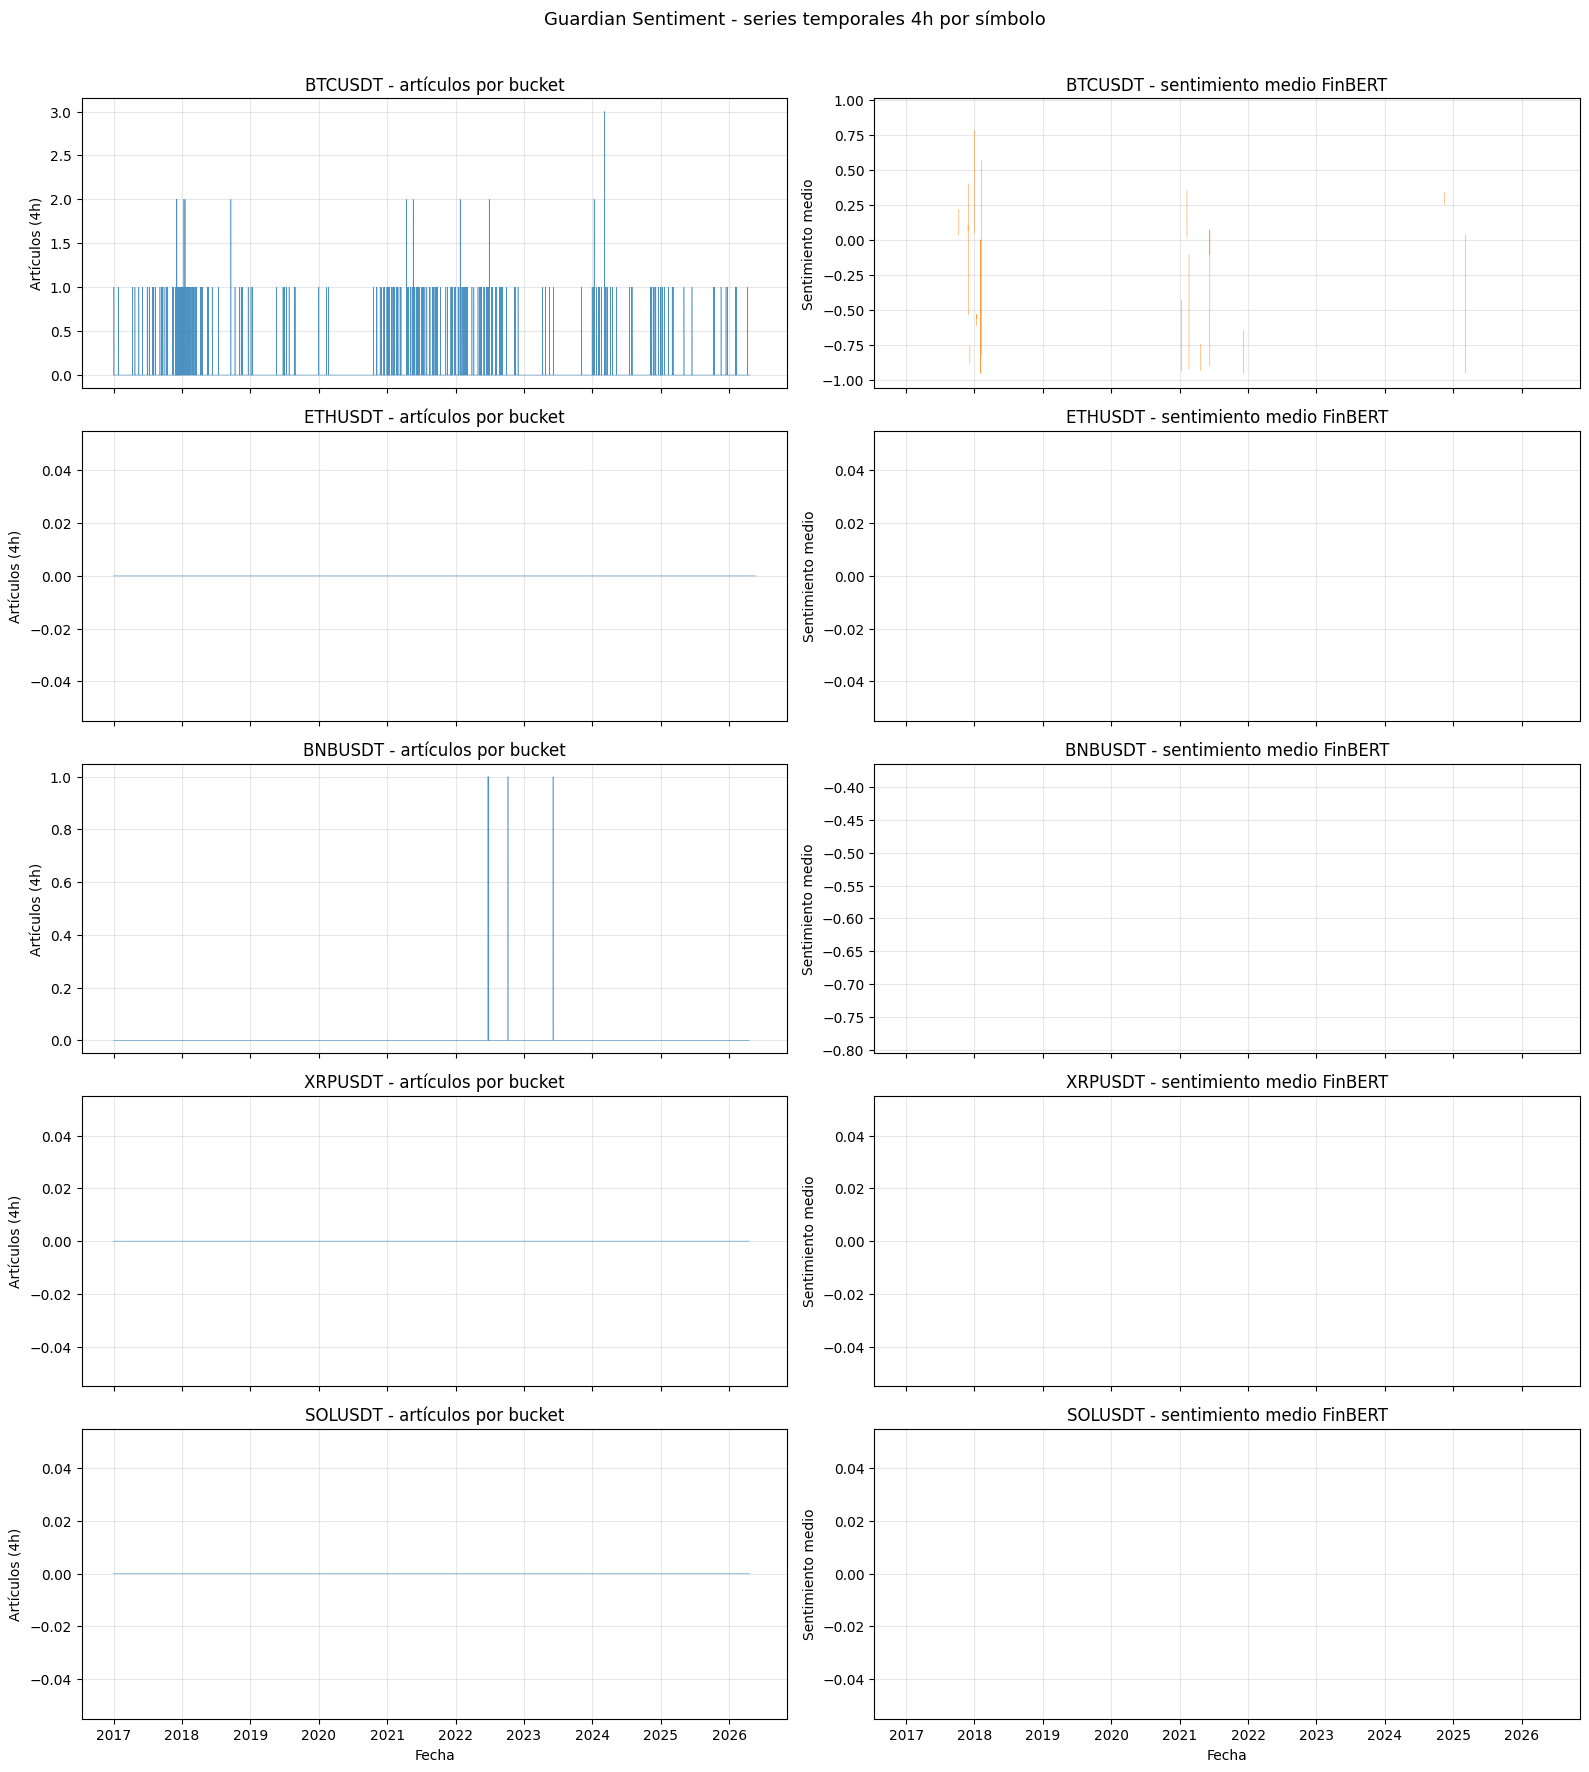

In [7]:
# Traza series 4h (artículos y sentimiento) por símbolo
series_dict: dict[str, pd.DataFrame] = {}

if engine:
    for symbol in GUARDIAN_SYMBOLS:
        series_query = text(
            f"""
            SELECT bucket_4h,
                   article_count,
                   sentiment_mean,
                   unique_contributors
            FROM {GUARDIAN_FULL_TABLE}
            WHERE symbol = :symbol AND scope = 'symbol'
            ORDER BY bucket_4h
            """
        )
        df = pd.read_sql(series_query, engine, params={"symbol": symbol})
        if not df.empty:
            df["bucket_4h"] = pd.to_datetime(df["bucket_4h"])
            series_dict[symbol] = df

if series_dict:
    fig, axes = plt.subplots(
        len(series_dict), 2,
        figsize=(16, 3.5 * len(series_dict)),
        sharex=True,
    )
    if len(series_dict) == 1:
        axes = [axes]

    for row_axes, (symbol, df) in zip(axes, series_dict.items()):
        ax_count, ax_sent = row_axes

        ax_count.plot(df["bucket_4h"], df["article_count"], linewidth=0.4, alpha=0.8)
        ax_count.set_ylabel("Artículos (4h)")
        ax_count.set_title(f"{symbol} - artículos por bucket")
        ax_count.xaxis.set_major_locator(mdates.YearLocator())
        ax_count.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax_count.grid(True, alpha=0.3)

        ax_sent.plot(
            df["bucket_4h"], df["sentiment_mean"],
            linewidth=0.4, alpha=0.8, color="tab:orange",
        )
        ax_sent.set_ylabel("Sentimiento medio")
        ax_sent.set_title(f"{symbol} - sentimiento medio FinBERT")
        ax_sent.xaxis.set_major_locator(mdates.YearLocator())
        ax_sent.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax_sent.grid(True, alpha=0.3)

    axes[-1][0].set_xlabel("Fecha")
    axes[-1][1].set_xlabel("Fecha")
    fig.suptitle(
        "Guardian Sentiment - series temporales 4h por símbolo",
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    plt.show()
else:
    print("Sin datos para graficar series temporales")


### 5.2. Muestra de filas recientes

La muestra final por entidad (`scope`, `symbol`) permite comprobar la forma de los registros más recientes sin convertir el cuaderno en una exploración exhaustiva de la tabla completa. Se muestra una única tabla concatenada para evitar ruido de salida y verificar que conviven las columnas principales: conteo de artículos, textos analizados, probabilidades de sentimiento, cobertura y momento de ingesta.

In [8]:
# Muestra las filas recientes de cada entidad (símbolo o agregado de mercado)
muestras: dict[str, pd.DataFrame] = {}

if engine:
    for symbol in [symbol for _, symbol in GUARDIAN_ENTITIES]:
        scope = "symbol" if symbol != GUARDIAN_MARKET_SYMBOL else "market_wide"
        muestra_reciente_query = text(
            f"""
            SELECT scope, symbol, bucket_4h,
                   article_count, texts_analyzed,
                   sentiment_mean, sentiment_positive,
                   sentiment_negative, sentiment_neutral,
                   unique_contributors, unique_keywords,
                   coverage_ratio,
                   ingested_at
            FROM {GUARDIAN_FULL_TABLE}
            WHERE symbol = :symbol AND scope = :scope
            ORDER BY bucket_4h DESC
            LIMIT 5
            """
        )
        muestras[symbol] = pd.read_sql(
            muestra_reciente_query, engine, params={"symbol": symbol, "scope": scope}
        )

muestra_reciente_df = pd.concat(muestras.values(), ignore_index=True) if muestras else pd.DataFrame()
muestra_reciente_vista_df = muestra_reciente_df.rename(columns={
    "scope": "ámbito",
    "symbol": "símbolo",
    "article_count": "artículos",
    "texts_analyzed": "textos_analizados",
    "sentiment_mean": "sentimiento_medio",
    "sentiment_positive": "sentimiento_positivo",
    "sentiment_negative": "sentimiento_negativo",
    "sentiment_neutral": "sentimiento_neutral",
    "unique_contributors": "autores_únicos",
    "unique_keywords": "keywords_únicas",
    "coverage_ratio": "ratio_cobertura",
    "ingested_at": "ingestado_en",
})
muestra_reciente_vista_df


,ámbito,símbolo,bucket_4h,artículos,textos_analizados,sentimiento_medio,sentimiento_positivo,sentimiento_negativo,sentimiento_neutral,autores_únicos,keywords_únicas,ratio_cobertura,ingestado_en
0,market_wide,MARKET,2026-05-20 20:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-05-20 22:25:55.762122+00:00
1,market_wide,MARKET,2026-05-19 20:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-05-20 21:35:11.576122+00:00
2,market_wide,MARKET,2026-05-19 16:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-05-20 21:35:11.576122+00:00
3,market_wide,MARKET,2026-05-19 12:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-05-20 21:35:11.576122+00:00
4,market_wide,MARKET,2026-05-19 08:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-05-20 21:35:11.576122+00:00
5,symbol,BTCUSDT,2026-04-22 16:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-04-22 17:19:05.548518+00:00
6,symbol,BTCUSDT,2026-04-21 20:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-04-22 17:19:03.550697+00:00
7,symbol,BTCUSDT,2026-04-21 16:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-04-22 17:19:03.550694+00:00
8,symbol,BTCUSDT,2026-04-21 12:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-04-22 17:19:03.550692+00:00
9,symbol,BTCUSDT,2026-04-21 08:00:00+00:00,0,0,None,None,None,None,0,0,None,2026-04-22 17:19:03.550689+00:00


## 6. Auditoría de ingesta

La auditoría completa la lectura técnica: no basta con que la fact tenga datos, también debe existir rastro de ejecuciones. Distinguimos entre el modo histórico y el modo en vivo, porque la cobertura de noticias puede evolucionar sin tocar el histórico ya cargado.


In [9]:
# Recorre la auditoría: modo histórico o en vivo, diagnóstico básico de la cola en vivo
evidencia_auditoria_df_full = pd.DataFrame()

if engine:
    try:
        q_runs = text(
            """
            SELECT run_id,
                   pipeline_type,
                   started_at,
                   finished_at,
                   symbol_count,
                   tasks_total,
                   success_count,
                   failed_count,
                   total_rows
            FROM alternative_data.ingestion_runs
            WHERE pipeline_type IN (
                'etl_guardian_sentiment',
                'etl_guardian_sentiment_live',
                'etl_guardian_sentiment_backfill',
                'etl_guardian'
            )
            ORDER BY started_at DESC
            LIMIT 50;
            """
        )
        evidencia_auditoria_df_full = pd.read_sql(q_runs, engine)
    except Exception as exc:
        evidencia_auditoria_df_full = pd.DataFrame([{"aviso": f"Error consultando ingestion_runs: {exc}"}])

resumen_modos_df = pd.DataFrame()
diagnostico_live_df = pd.DataFrame()
diagnostico_live_resumen: dict = {}

if not evidencia_auditoria_df_full.empty:
    evidencia_auditoria_df_full["modo"] = evidencia_auditoria_df_full["pipeline_type"].map(
        lambda x: "live" if "live" in str(x).lower() else "histórico"
    )
    evidencia_auditoria_df_full["run_con_fallo"] = (
        evidencia_auditoria_df_full["failed_count"].fillna(0).astype(int) > 0
    )

    resumen_modos_df = (
        evidencia_auditoria_df_full.groupby("modo", as_index=False)
        .agg(
            runs=("run_id", "count"),
            ultimo_inicio=("started_at", "max"),
            total_filas=("total_rows", "sum"),
            total_fallos_eventos=("failed_count", "sum"),
            runs_con_fallo=("run_con_fallo", "sum"),
        )
        .sort_values("modo")
    )
    resumen_modos_df["pct_runs_con_fallo"] = (
        (resumen_modos_df["runs_con_fallo"] / resumen_modos_df["runs"]) * 100.0
    ).round(2)

    live_runs_df = evidencia_auditoria_df_full[
        evidencia_auditoria_df_full["modo"] == "live"
    ].copy()
    if not live_runs_df.empty:
        live_runs_df["started_ts"] = pd.to_datetime(live_runs_df["started_at"], utc=True)
        live_runs_df["finished_ts"] = pd.to_datetime(live_runs_df["finished_at"], utc=True)
        live_runs_df["duracion_s"] = (
            live_runs_df["finished_ts"] - live_runs_df["started_ts"]
        ).dt.total_seconds().round(1)

        live_failed_df = live_runs_df[live_runs_df["run_con_fallo"]]
        live_success_df = live_runs_df[~live_runs_df["run_con_fallo"]]

        ventana_fallos_s = None
        primer_exito_tras_fallos = None
        exitos_post_fallos = 0
        if not live_failed_df.empty:
            ventana_fallos_s = round(
                (live_failed_df["started_ts"].max() - live_failed_df["started_ts"].min()).total_seconds(), 1
            )
            if not live_success_df.empty:
                success_after_failures = live_success_df["started_ts"] > live_failed_df["started_ts"].max()
                exitos_post_fallos = int(success_after_failures.sum())
                if success_after_failures.any():
                    primer_exito_tras_fallos = live_success_df.loc[success_after_failures, "started_ts"].min()

        diagnostico_live_resumen = {
            "total_live_runs": len(live_runs_df),
            "runs_exitosos": len(live_success_df),
            "runs_fallidos": len(live_failed_df),
            "ventana_fallos_s": ventana_fallos_s,
            "duracion_media_fallos_s": round(live_failed_df["duracion_s"].mean(), 2) if not live_failed_df.empty else None,
            "duracion_media_exitos_s": round(live_success_df["duracion_s"].mean(), 2) if not live_success_df.empty else None,
            "exitos_consecutivos_post_fallos": exitos_post_fallos,
            "primer_exito_tras_fallos": str(primer_exito_tras_fallos) if primer_exito_tras_fallos else None,
        }
        diagnostico_live_df = live_runs_df[
            ["run_id", "pipeline_type", "started_at", "finished_at",
             "success_count", "failed_count", "total_rows", "duracion_s", "run_con_fallo"]
        ].sort_values("started_at", ascending=True)

# Aplica un mapeo fijo de columnas técnicas a nombres en castellano (tablas y CSV de auditoría)
COLUMNAS_AUDITORIA_ES = {
    "run_id": "id_ejecución",
    "pipeline_type": "tipo_pipeline",
    "started_at": "inicio",
    "finished_at": "fin",
    "symbol_count": "símbolos",
    "tasks_total": "tareas",
    "success_count": "eventos_ok",
    "failed_count": "eventos_fallidos",
    "total_rows": "total_filas",
    "duracion_s": "duración_s",
    "run_con_fallo": "ejecución_con_fallo",
}

if not resumen_modos_df.empty:
    print("Resumen por modo de ejecución")
    display(resumen_modos_df)
if not diagnostico_live_df.empty:
    print("\nDiagnóstico de ejecuciones en vivo")
    display(diagnostico_live_df.rename(columns=COLUMNAS_AUDITORIA_ES))
if resumen_modos_df.empty and diagnostico_live_df.empty:
    display(pd.DataFrame([{"aviso": "Sin registros de auditoría para Guardian Sentiment."}]))


Resumen por modo de ejecución


,modo,runs,ultimo_inicio,total_filas,total_fallos_eventos,runs_con_fallo,pct_runs_con_fallo
0,histórico,14,2026-04-19 22:09:39.558332+00:00,165050,38,9,64.29
1,live,5,2026-05-20 22:28:57.218306+00:00,396,0,0,0.00



Diagnóstico de ejecuciones en vivo


,id_ejecución,tipo_pipeline,inicio,fin,eventos_ok,eventos_fallidos,total_filas,duración_s,ejecución_con_fallo
4,b618472f-625d-408d-9109-24ca45c80bda,etl_guardian_sentiment_live,2026-04-22 17:18:58.473693+00:00,2026-04-22 17:19:05.660673+00:00,2,0,38,7.2,False
3,df9a2f7f-e4bf-428e-93e6-211346126b2f,etl_guardian_sentiment_live,2026-05-20 21:34:42.392157+00:00,2026-05-20 21:35:45.538930+00:00,2,0,356,63.1,False
2,07d154a9-9c1d-4f83-96bf-96dfc814068b,etl_guardian_sentiment_live,2026-05-20 21:57:30.713088+00:00,2026-05-20 21:57:33.502622+00:00,0,0,0,2.8,False
1,dea68254-be3c-4bb7-a288-b459b55d0bd4,etl_guardian_sentiment_live,2026-05-20 22:25:55.195622+00:00,2026-05-20 22:25:58.658056+00:00,0,0,2,3.5,False
0,9e8897e3-fee5-4ff1-8403-c09b37d014ee,etl_guardian_sentiment_live,2026-05-20 22:28:57.218306+00:00,2026-05-20 22:28:59.913608+00:00,0,0,0,2.7,False


## 7. Inventario de artefactos Parquet en disco

Además de la evidencia SQL, el pipeline deja snapshots `parquet` canónicos en disco. Este inventario comprueba que existe un respaldo por ámbito y símbolo, con tamaño, filas y rango temporal observados.


In [10]:
# Recorre bajo `GUARDIAN_RAW_DIR` y fija rango, columnas y MB por snapshot
parquet_rows: list[dict] = []

for scope, symbol in GUARDIAN_ENTITIES:
    parquet_filename = f"guardian_sentiment_{scope}_{symbol}.parquet".replace("/", "_")
    parquet_path = GUARDIAN_RAW_DIR / parquet_filename
    parquet_record = {
        "tipo": "raw_guardian_snapshot",
        "símbolo": symbol,
        "archivo": parquet_filename,
        "tamaño_mb": None,
        "filas": None,
        "columnas": None,
        "min_timestamp": None,
        "max_timestamp": None,
    }

    if parquet_path.exists():
        parquet_record["tamaño_mb"] = round(parquet_path.stat().st_size / (1024 * 1024), 2)
        try:
            parquet_df = pd.read_parquet(parquet_path)
            bucket_timestamps = (
                pd.to_datetime(parquet_df["bucket_4h"], utc=True, errors="coerce").dropna()
                if "bucket_4h" in parquet_df.columns
                else pd.Series(dtype="datetime64[ns, UTC]")
            )
            parquet_record.update(
                {
                    "filas": len(parquet_df),
                    "columnas": len(parquet_df.columns),
                    "min_timestamp": bucket_timestamps.min()
                    if not bucket_timestamps.empty
                    else None,
                    "max_timestamp": bucket_timestamps.max()
                    if not bucket_timestamps.empty
                    else None,
                }
            )
        except Exception as exc:
            parquet_record["detalle"] = f"No se pudo leer el Parquet: {exc}"

    parquet_rows.append(parquet_record)

parquet_inventory_df = pd.DataFrame(parquet_rows)
parquet_inventory_df


,tipo,símbolo,archivo,tamaño_mb,filas,columnas,min_timestamp,max_timestamp
0,raw_guardian_snapshot,MARKET,guardian_sentiment_market_wide_MARKET.parquet,0.25,20557,20,2017-01-01 00:00:00+00:00,2026-05-20 20:00:00+00:00
1,raw_guardian_snapshot,BTCUSDT,guardian_sentiment_symbol_BTCUSDT.parquet,0.24,20389,20,2017-01-01 00:00:00+00:00,2026-04-22 16:00:00+00:00
2,raw_guardian_snapshot,ETHUSDT,guardian_sentiment_symbol_ETHUSDT.parquet,0.23,20557,20,2017-01-01 00:00:00+00:00,2026-05-20 20:00:00+00:00
3,raw_guardian_snapshot,BNBUSDT,guardian_sentiment_symbol_BNBUSDT.parquet,0.23,20370,20,2017-01-01 00:00:00+00:00,2026-04-18 20:00:00+00:00
4,raw_guardian_snapshot,XRPUSDT,guardian_sentiment_symbol_XRPUSDT.parquet,0.23,20370,20,2017-01-01 00:00:00+00:00,2026-04-18 20:00:00+00:00
5,raw_guardian_snapshot,SOLUSDT,guardian_sentiment_symbol_SOLUSDT.parquet,0.23,20370,20,2017-01-01 00:00:00+00:00,2026-04-18 20:00:00+00:00


## 8. Exportación de artefactos para reproducibilidad

Las tablas vistas son útiles en el cuaderno, pero la memoria del TFG y la auditoría externa necesitan **artefactos persistentes** en disco. En esta celda se vuelca todo lo anterior bajo `reports/validation/guardian/`, con un timestamp UTC en el nombre para no sobrescribir corridas previas:

- Un **JSON consolidado** (`guardian_validation_<stamp>.json`) que agrupa metadatos, `FECHA_CORTE`, universo de símbolos, resultado global, fallos accionables, comprobaciones, completitud ETL, `duplicados_pk`, `integridad_imputaciones` (cobertura de señal), `diagnostico_live` e `inventario_parquet`.
- Ocho **CSV** (mismo `<stamp>`, p. ej. `20260603T232158Z` en esta corrida): `guardian_validation_summary_`, `guardian_validation_cobertura_`, `guardian_validation_resumen_simbolos_`, `guardian_validation_duplicados_`, `guardian_validation_integridad_`, `guardian_validation_modos_`, `guardian_validation_diagnostico_live_` y `guardian_validation_parquet_inventory_` (prefijo común + sufijo `.csv`).

Al final se imprime el **resultado global** (`PASS`/`FAIL`) y una comprobación breve de las cuatro evidencias clave (histórico, en vivo, duplicados, integridad), además de las **rutas** del JSON y de cada CSV. Por último se libera la conexión con `engine.dispose()` para no dejar conexiones abiertas si el kernel se mantiene vivo.


In [11]:
# Vuelca JSON, CSVs si aplica, rutas fijas y un mismo `RUN_STAMP` en nombres de fichero
GUARDIAN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
export_paths = {
    "json": GUARDIAN_OUTPUT_DIR / f"guardian_validation_{RUN_STAMP}.json",
    "summary": GUARDIAN_OUTPUT_DIR / f"guardian_validation_summary_{RUN_STAMP}.csv",
    "cobertura": GUARDIAN_OUTPUT_DIR / f"guardian_validation_cobertura_{RUN_STAMP}.csv",
    "resumen_simbolos": GUARDIAN_OUTPUT_DIR / f"guardian_validation_resumen_simbolos_{RUN_STAMP}.csv",
    "duplicados": GUARDIAN_OUTPUT_DIR / f"guardian_validation_duplicados_{RUN_STAMP}.csv",
    "integridad": GUARDIAN_OUTPUT_DIR / f"guardian_validation_integridad_{RUN_STAMP}.csv",
    "modos": GUARDIAN_OUTPUT_DIR / f"guardian_validation_modos_{RUN_STAMP}.csv",
    "diagnostico_live": GUARDIAN_OUTPUT_DIR / f"guardian_validation_diagnostico_live_{RUN_STAMP}.csv",
    "parquet_inventory": GUARDIAN_OUTPUT_DIR / f"guardian_validation_parquet_inventory_{RUN_STAMP}.csv",
}

historico_ok = bool((not resumen_modos_df.empty) and (resumen_modos_df["modo"] == "histórico").any())
live_ok = bool((not resumen_modos_df.empty) and (resumen_modos_df["modo"] == "live").any())
duplicados_ok = bool(not duplicados_pk_df.empty and (duplicados_pk_df["duplicados_pk"] == 0).all())
integridad_ok = bool(
    not integridad_df.empty
    and len(integridad_df) == len([symbol for _, symbol in GUARDIAN_ENTITIES])
)

resumen_simbolos_df = pd.DataFrame()
try:
    if not evidencia_cobertura_vista_df.empty:
        resumen_simbolos_df = evidencia_cobertura_vista_df.assign(tabla=GUARDIAN_FULL_TABLE)
except NameError:
    pass

# Consolida el cierre: metadatos, comprobaciones, ETL, duplicados, integridad, parquets
payload = {
    "metadata": run_meta,
    "fecha_corte": FECHA_CORTE,
    "symbols": [symbol for _, symbol in GUARDIAN_ENTITIES],
    "resultado_global": "PASS" if accepted else "FAIL",
    "fallos_accionables": actionable_failures,
    "checks": summary_df.to_dict(orient="records"),
    "completitud_etl": {
        "historico_detectado": historico_ok,
        "live_detectado": live_ok,
    },
    "duplicados_pk": {
        "verificado": duplicados_ok,
        "cero_duplicados_todos_simbolos": duplicados_ok,
        "detalle": duplicados_pk_df.to_dict(orient="records") if not duplicados_pk_df.empty else [],
    },
    "integridad_imputaciones": {
        "verificado": integridad_ok,
        "detalle": integridad_df.to_dict(orient="records") if not integridad_df.empty else [],
    },
    "diagnostico_live": diagnostico_live_resumen,
    "inventario_parquet": {
        "archivos_encontrados": int((parquet_inventory_df["tamaño_mb"].notna()).sum()) if not parquet_inventory_df.empty else 0,
        "archivos_esperados": len(parquet_inventory_df) if not parquet_inventory_df.empty else 0,
        "detalle": parquet_inventory_df.to_dict(orient="records") if not parquet_inventory_df.empty else [],
    },
}

export_paths["json"].write_text(
    json.dumps(payload, indent=2, ensure_ascii=False, default=str),
    encoding="utf-8",
)
summary_df.to_csv(export_paths["summary"], index=False)
if not evidencia_cobertura_df.empty:
    evidencia_cobertura_df.to_csv(export_paths["cobertura"], index=False)
if not resumen_simbolos_df.empty:
    resumen_simbolos_df.to_csv(export_paths["resumen_simbolos"], index=False)
if not duplicados_pk_df.empty:
    duplicados_pk_df.to_csv(export_paths["duplicados"], index=False)
if not integridad_df.empty:
    integridad_df.rename(columns={"simbolo": "símbolo"}).to_csv(
        export_paths["integridad"], index=False
    )
if not resumen_modos_df.empty:
    resumen_modos_df.to_csv(export_paths["modos"], index=False)
if not diagnostico_live_df.empty:
    diagnostico_live_df.rename(columns=COLUMNAS_AUDITORIA_ES).to_csv(
        export_paths["diagnostico_live"], index=False
    )
if not parquet_inventory_df.empty:
    parquet_inventory_df.to_csv(export_paths["parquet_inventory"], index=False)

print(f"Resultado global: {'PASS' if accepted else 'FAIL'}")
print(f"Completitud (histórico): {'OK' if historico_ok else 'PENDIENTE'}")
print(f"Completitud (en vivo): {'OK' if live_ok else 'PENDIENTE'}")
print(f"Duplicados = 0 verificado: {'OK' if duplicados_ok else 'PENDIENTE'}")
print(f"Integridad por símbolo: {'OK' if integridad_ok else 'PENDIENTE'}")
print(f"Evidencia JSON: {export_paths['json']}")
print(f"Resumen comprobaciones (CSV): {export_paths['summary']}")
if not evidencia_cobertura_df.empty:
    print(f"Cobertura (CSV): {export_paths['cobertura']}")
if not resumen_simbolos_df.empty:
    print(f"Resumen por símbolo (CSV): {export_paths['resumen_simbolos']}")
if not duplicados_pk_df.empty:
    print(f"Duplicados de clave (CSV): {export_paths['duplicados']}")
if not integridad_df.empty:
    print(f"Integridad (CSV): {export_paths['integridad']}")
if not resumen_modos_df.empty:
    print(f"Modos histórico o en vivo (CSV): {export_paths['modos']}")
if not diagnostico_live_df.empty:
    print(f"Diagnóstico en vivo (CSV): {export_paths['diagnostico_live']}")
if not parquet_inventory_df.empty:
    print(f"Inventario de Parquet (CSV): {export_paths['parquet_inventory']}")

if engine:  # Reintegra la conexión al pool al cierre de la exportación
    engine.dispose()


Resultado global: FAIL
Completitud (histórico): OK
Completitud (en vivo): OK
Duplicados = 0 verificado: OK
Integridad por símbolo: OK
Evidencia JSON: /app/reports/validation/guardian/guardian_validation_20260603T233154Z.json
Resumen comprobaciones (CSV): /app/reports/validation/guardian/guardian_validation_summary_20260603T233154Z.csv
Cobertura (CSV): /app/reports/validation/guardian/guardian_validation_cobertura_20260603T233154Z.csv
Resumen por símbolo (CSV): /app/reports/validation/guardian/guardian_validation_resumen_simbolos_20260603T233154Z.csv
Duplicados de clave (CSV): /app/reports/validation/guardian/guardian_validation_duplicados_20260603T233154Z.csv
Integridad (CSV): /app/reports/validation/guardian/guardian_validation_integridad_20260603T233154Z.csv
Modos histórico o en vivo (CSV): /app/reports/validation/guardian/guardian_validation_modos_20260603T233154Z.csv
Diagnóstico en vivo (CSV): /app/reports/validation/guardian/guardian_validation_diagnostico_live_20260603T233154Z.cs

## 9. Conclusiones

Para el universo configurado en el validador (símbolos por activo y `market_wide` en temporalidad 4h) con **fecha de corte** **2026-02-28**, esta ejecución (`stamp` `20260603T232158Z`, `fecha_hora_utc` **2026-06-03 23:21 UTC**) deja fijada una lectura en tres capas:

1. **Ingesta estructural**: el validador cierra con resultado global `FAIL` porque `SENTIMENT_COVERAGE` es la única comprobación requerida en fallo; el resto de checks requeridos figuran en `PASS`. Las evidencias SQL muestran **122,613** filas en `fact_guardian_sentiment` (seis entidades: cinco símbolos + `MARKET`), **0** duplicados por PK e integridad por entidad en OK. La auditoría registra **19** corridas (**14** histórico, **5** *live*); histórico acumula **165,050** filas reportadas con **64.29 %** de corridas con fallo de evento, frente a **396** filas en *live* sin fallos en esta corrida.
2. **Cobertura de señal (*FinBERT*)**: la ausencia de `sentiment_mean` se interpreta como *falta de score disponible* en un bucket con actividad, no como un hueco de mercado equivalente a una vela faltante en precio. En esta corrida, `pct_buckets_con_score` alcanza **3.18 %** en `MARKET`, **1.48 %** en `BTCUSDT`, **0.02 %** en `BNBUSDT` y **0 %** en `ETHUSDT`, `SOLUSDT` y `XRPUSDT`; el `FAIL` de `SENTIMENT_COVERAGE` documenta que el ratio mínimo configurado no se cumple para todos los símbolos.
3. **Reproducibilidad**: el inventario de *Parquet* en disco (snapshot canónico por `scope`/`symbol`) asegura trazabilidad; los **CSV/JSON** bajo `reports/validation/guardian/` son los artefactos citables en memoria (ocho CSV + JSON en esta corrida).

**Nota.** Resultado global, estados de `summary_df` y rutas con `stamp` dependen del estado del proyecto al ejecutar el cuaderno; en otra corrida pueden cambiar.
